<a href="https://colab.research.google.com/github/q1mora/cnt-property-prediction-using-ml-architectures/blob/ml/KANs_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# KANs model script for predicting chirality indices (n, m)
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


!pip install pykan

from kan import KAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
    f1_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
# configuration
batch_size = 32
num_epochs = 300

seed = 43
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# loading data
data = pd.read_csv("/content/CNT_Chiral_Index.csv")

features = ["n", "m"]
target = "Metal (1) or Semi (0)"

# drop rows where the target variable is NaN
data.dropna(subset=[target], inplace=True)

# filter out rows where the target is not 0 or 1
data = data[data[target].isin([0, 1])]

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32)

In [ ]:
# train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)


generating data distribution plots...
saved 'distribution_train.png'
saved 'distribution_test.png'


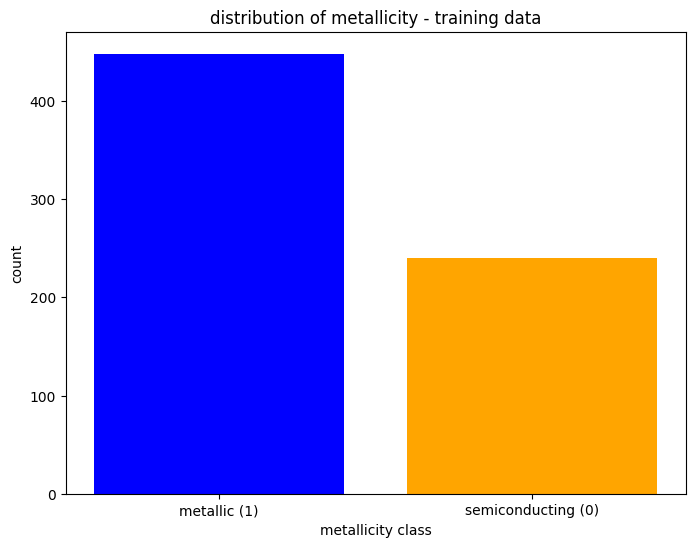

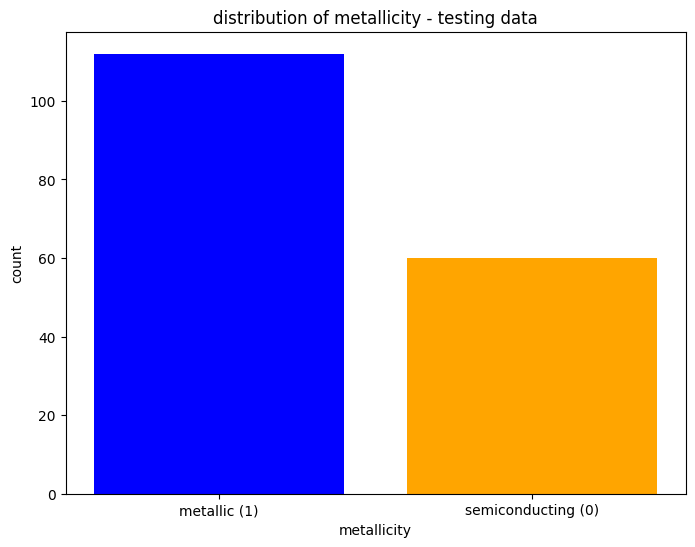

In [ ]:
# plotting data distributions
print("\ngenerating data distribution plots...")

# plot training data distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 6))
labels_train = ['metallic (1)', 'semiconducting (0)']
plt.bar(labels_train, counts_train, color=['blue','orange'])

plt.xlabel('metallicity class')
plt.ylabel('count')
plt.title('distribution of metallicity - training data')

plt.savefig('distribution_train.png')
print("saved 'distribution_train.png'")

# plot testing data distribution
unique_test, counts_test = np.unique(y_test, return_counts=True)

plt.figure(figsize=(8, 6))
labels_test = ['metallic (1)','semiconducting (0)']
plt.bar(labels_test, counts_test, color=['blue', 'orange'])

plt.xlabel('metallicity')
plt.ylabel('count')
plt.title('distribution of metallicity - testing data')

plt.savefig('distribution_test.png')
print("saved 'distribution_test.png'")

In [ ]:
# building data loaders
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

# define KANs model
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)
model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


checkpoint directory created: ./model
saving model version 0.0
using device: cpu


In [ ]:
# training
print("\nstarting training...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        # reshape labels to be [batch_size, 1] for BCEWithLogitsLoss
        labels = labels.to(device).float()

        outputs = model(feats)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"epoch [{epoch+1}/{num_epochs}], loss = {running_loss/len(train_loader):.4f}")

train_end = time.time()
train_time = train_end - start_time
print(f"\ntraining finished in {train_time:.2f} seconds")


starting training...
epoch [10/300], loss = 0.6536
epoch [20/300], loss = 0.6424
epoch [30/300], loss = 0.6373
epoch [40/300], loss = 0.6393
epoch [50/300], loss = 0.6367
epoch [60/300], loss = 0.6347
epoch [70/300], loss = 0.6351
epoch [80/300], loss = 0.6351
epoch [90/300], loss = 0.6364
epoch [100/300], loss = 0.6339
epoch [110/300], loss = 0.6318
epoch [120/300], loss = 0.6272
epoch [130/300], loss = 0.6287
epoch [140/300], loss = 0.6270
epoch [150/300], loss = 0.6260
epoch [160/300], loss = 0.6242
epoch [170/300], loss = 0.6305
epoch [180/300], loss = 0.6273
epoch [190/300], loss = 0.6244
epoch [200/300], loss = 0.6240
epoch [210/300], loss = 0.6267
epoch [220/300], loss = 0.6215
epoch [230/300], loss = 0.6211
epoch [240/300], loss = 0.6240
epoch [250/300], loss = 0.6228
epoch [260/300], loss = 0.6251
epoch [270/300], loss = 0.6201
epoch [280/300], loss = 0.6222
epoch [290/300], loss = 0.6214
epoch [300/300], loss = 0.6201

training finished in 84.54 seconds


In [ ]:
# testing
print("\nstarting testing...")
model.eval()

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for feats, labels in test_loader:
        feats, labels = feats.to(device), labels.to(device)

        logits = model(feats)
        preds = torch.round(torch.sigmoid(logits))

        y_pred_list.extend(preds.cpu().numpy().ravel())
        y_true_list.extend(labels.cpu().numpy().ravel())

test_end = time.time()
test_time = test_end - train_end
total_time = test_end - start_time

# convert arrays
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)


starting testing...


In [ ]:
# calculate initial metrics (using default threshold 0.5 from model.predict)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"\ninitial test accuracy (default threshold 0.5): {initial_accuracy*100:.2f}%")

print("\nclassification report (default threshold 0.5):")
print(classification_report(y_test, y_pred, target_names=["Semi (0)", "Metal (1)"]))

# find best F1 threshold
best_f1 = 0
best_t = 0.5

for t in np.linspace(0.1, 0.9, 81):
    current_preds = (probs > t).astype(int)
    f1 = f1_score(y_test, current_preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nbest threshold for F1-score: {best_t:.2f}")

# generate final predictions using the best threshold
final_preds = (probs > best_t).astype(int)

# calculate metrics with optimized threshold
optimized_accuracy = accuracy_score(y_test, final_preds)
print(f"\nfinal test accuracy (optimized threshold): {optimized_accuracy*100:.2f}%")

print("\nclassification report (optimized threshold):")
print(classification_report(y_test, final_preds, target_names=["Semi (0)", "Metal (1)"]))

# calculate confusion matrix for plotting
cm = confusion_matrix(y_test, final_preds)

# calculate ROC curve and AUC for plotting
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# time summary
print("\ntime summary")
print(f"training time:         {train_time:.2f} seconds")
print(f"testing (prediction) time: {test_time:.2f} seconds")
print(f"total runtime (train + test): {total_time:.2f} seconds")


initial test accuracy (default threshold 0.5): 65.70%

classification report (default threshold 0.5):
              precision    recall  f1-score   support

    Semi (0)       0.66      0.97      0.79       112
   Metal (1)       0.57      0.07      0.12        60

    accuracy                           0.66       172
   macro avg       0.62      0.52      0.45       172
weighted avg       0.63      0.66      0.55       172



NameError: name 'probs' is not defined

In [ ]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("KANs 'n', 'm', 'diameter (A)', 'chiral angle (deg.)' confusion matrix")
plt.savefig('kans_conf')
plt.show()


In [ ]:
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"KANs ROC curve 'n', 'm', 'diameter (A)', 'chiral angle (deg.)' (AUC = {roc_auc:.3f})")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.savefig('kans_roc')
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

model.plot(
    folder=kan_plot_folder,
    in_vars=[
        'n',
        'm',
        'diam.\n(Å)',
        'chiral\n(deg.)'
    ],
    out_vars=['Metal (1) or Semi (0)']
)

plt.savefig('kans_bsplines')